In [1]:
import sys
sys.path.append("/vol/biomedic3/tx1215/mamo-flow")

import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from skimage import io
from torchvision import transforms

from src.utils import get_pretrained_flux2vae

In [2]:
PROJECT_ROOT = Path("/vol/biomedic3/tx1215/mamo-flow")

DATA_DIR = Path(
    "/vol/biodata/data/Mammo/EMBED/pngs/1024x768"
)

TRAIN_CSV = Path("/vol/biomedic3/tx1215/mamo-flow/assets/embed_splits_v1/train.csv")

DEVICE = "cuda:0"

IMG_HEIGHT = 256
IMG_WIDTH = 192

print("Device:", DEVICE)
print("Data dir:", DATA_DIR)
print("Train CSV:", TRAIN_CSV)

Device: cuda:0
Data dir: /vol/biodata/data/Mammo/EMBED/pngs/1024x768
Train CSV: /vol/biomedic3/tx1215/mamo-flow/assets/embed_splits_v1/train.csv


In [3]:
def preprocess_breast(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        from skimage.util import img_as_ubyte

        image = io.imread(image_path)
        gray = img_as_ubyte(
            image.astype(np.uint16)
        )

    else:
        gray = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2GRAY,
        )

    thresh = cv2.threshold(
        gray,
        5,
        255,
        cv2.THRESH_BINARY,
    )[1]

    nb_components, output, stats, _ = (
        cv2.connectedComponentsWithStats(
            thresh,
            connectivity=4,
        )
    )

    if nb_components <= 1:
        mask = np.ones_like(
            gray,
            dtype=bool,
        )

    else:
        max_label, _ = max(
            [
                (
                    i,
                    stats[i, cv2.CC_STAT_AREA],
                )
                for i in range(
                    1,
                    nb_components,
                )
            ],
            key=lambda x: x[1],
        )

        mask = output == max_label

    image = gray.copy()
    image[~mask] = 0

    return image.astype(np.uint8)

In [4]:
transform = transforms.Compose(
    [
        transforms.ToPILImage(),

        transforms.Resize(
            (IMG_HEIGHT, IMG_WIDTH),
            antialias=True,
        ),

        transforms.ToTensor(),
    ]
)

In [5]:
df = pd.read_csv(
    TRAIN_CSV,
    low_memory=False,
)

print("Number of samples:", len(df))
print(df.columns.tolist())

df.head()

Number of samples: 237746
['cache_idx', 'empi_anon', 'tissueden', 'study_date_anon', 'acc_anon', 'asses', 'age_at_study', 'image_path', 'FinalImageType', 'ImageLateralityFinal', 'ViewPosition', 'Manufacturer', 'ManufacturerModelName', 'image_path_orig', 'shortpath', 'manufacturer_domain', 'density', 'scanner', 'view', 'cview', 'age']


,cache_idx,empi_anon,tissueden,study_date_anon,acc_anon,asses,age_at_study,image_path,FinalImageType,ImageLateralityFinal,...,Manufacturer,ManufacturerModelName,image_path_orig,shortpath,manufacturer_domain,density,scanner,view,cview,age
0,0,60696029,C,2013-12-30,8099128854014801,A,69.652354,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,2D,R,...,"HOLOGIC, Inc.",Selenia Dimensions,60696029/1.2.826.0.1.3680043.8.498.57863081415...,cohort_1/60696029/1.2.845.113979.3.66.1.485763...,0,2,0,0,0,69.652354
1,1,60696029,C,2013-12-30,8099128854014801,A,69.652354,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,2D,R,...,"HOLOGIC, Inc.",Selenia Dimensions,60696029/1.2.826.0.1.3680043.8.498.34391769880...,cohort_1/60696029/1.2.845.113979.3.66.1.485763...,0,2,0,0,0,69.652354
2,2,60696029,C,2013-12-30,8099128854014801,A,69.652354,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,2D,R,...,"HOLOGIC, Inc.",Selenia Dimensions,60696029/1.2.826.0.1.3680043.8.498.98599453977...,cohort_1/60696029/1.2.845.113979.3.66.1.485763...,0,2,0,1,0,69.652354
3,3,90986305,C,2013-08-26,5156106114290009,P,42.741466,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,2D,L,...,"HOLOGIC, Inc.",Selenia Dimensions,90986305/1.2.826.0.1.3680043.8.498.41500728563...,cohort_1/90986305/1.2.843.113973.3.65.1.476726...,0,2,0,0,0,42.741466
4,4,90986305,C,2013-08-26,5156106114290009,P,42.741466,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,2D,L,...,"HOLOGIC, Inc.",Selenia Dimensions,90986305/1.2.826.0.1.3680043.8.498.12917616441...,cohort_1/90986305/1.2.843.113973.3.65.1.476726...,0,2,0,1,0,42.741466


In [6]:
idx = 0

row = df.iloc[idx]

image_path = row["image_path"]

if not os.path.isabs(str(image_path)):
    image_path = DATA_DIR / image_path

print(image_path)

/vol/biodata/data/Mammo/EMBED/pngs/1024x768/cohort_1/60696029/1.2.845.113979.3.66.1.48576351.20131116.1100119/1.2.849.113688.2750825174.1384237796.3781.1309/1.2.826.0.1.3680043.8.498.57863081415434463223208365979079263200.png


shape: (1024, 768)
dtype: uint8
min/max: 0 255


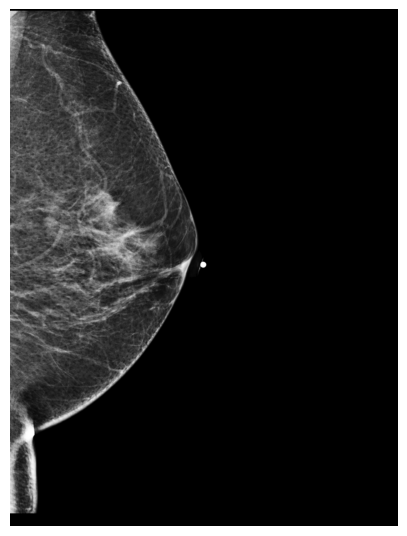

In [7]:
image_np = preprocess_breast(
    image_path
)

print("shape:", image_np.shape)
print("dtype:", image_np.dtype)
print(
    "min/max:",
    image_np.min(),
    image_np.max(),
)

plt.figure(figsize=(5, 7))
plt.imshow(
    image_np,
    cmap="gray",
)
plt.axis("off")
plt.show()

In [8]:
x = transform(image_np)

print("Before batch:")
print("shape:", x.shape)
print(
    "range:",
    x.min().item(),
    x.max().item(),
)

Before batch:
shape: torch.Size([1, 256, 192])
range: 0.0 1.0


In [9]:
x = x.unsqueeze(0)

print(x.shape)

torch.Size([1, 1, 256, 192])


In [10]:
x = x * 2.0 - 1.0

x = x.to(DEVICE)

print("VAE input:")
print("shape:", x.shape)
print(
    "range:",
    x.min().item(),
    x.max().item(),
)

VAE input:
shape: torch.Size([1, 1, 256, 192])
range: -1.0 1.0


In [11]:
vae = get_pretrained_flux2vae()

vae = vae.to(DEVICE)

print(type(vae))

print(
    "dtype:",
    next(vae.parameters()).dtype,
)

print(
    "device:",
    next(vae.parameters()).device,
)

print(
    "mean:",
    vae.mean.item(),
)

print(
    "std:",
    vae.std.item(),
)

/vol/biomedic3/tx1215/mamo-flow/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading FLUX.2 vae...


/vol/biomedic3/tx1215/mamo-flow/.venv/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


<class 'diffusers.models.autoencoders.autoencoder_kl_flux2.AutoencoderKLFlux2'>
dtype: torch.bfloat16
device: cuda:0
mean: -0.0614669993519783
std: 1.6336369514465332


In [12]:
x = x = x.to(
    dtype=next(vae.parameters()).dtype
)

with torch.inference_mode():
    z = vae.encode(x)

print("latent:")
print("shape:", z.shape)
print("dtype:", z.dtype)

print(
    "min/max:",
    z.min().item(),
    z.max().item(),
)

print(
    "mean:",
    z.float().mean().item(),
)

print(
    "std:",
    z.float().std().item(),
)

latent:
shape: torch.Size([1, 32, 32, 24])
dtype: torch.bfloat16
min/max: -7.28125 7.3125
mean: 0.004196229390799999
std: 1.420762300491333


In [13]:
z_norm = (
    z.float() - vae.mean.float()
) / vae.std.float()

print(
    "raw latent mean/std:",
    z.float().mean().item(),
    z.float().std().item(),
)

print(
    "normalized latent mean/std:",
    z_norm.mean().item(),
    z_norm.std().item(),
)

raw latent mean/std: 0.004196229390799999 1.420762300491333
normalized latent mean/std: 0.04019451141357422 0.8696927428245544


In [14]:
with torch.inference_mode():
    x_rec = vae.decode(z)

print("reconstruction:")
print("shape:", x_rec.shape)
print("dtype:", x_rec.dtype)

print(
    "range:",
    x_rec.float().min().item(),
    x_rec.float().max().item(),
)

reconstruction:
shape: torch.Size([1, 1, 256, 192])
dtype: torch.bfloat16
range: -1.015625 1.0234375


In [15]:
x_vis = (
    (x.float() + 1.0) / 2.0
).clamp(0, 1)

x_rec_vis = (
    (x_rec.float() + 1.0) / 2.0
).clamp(0, 1)

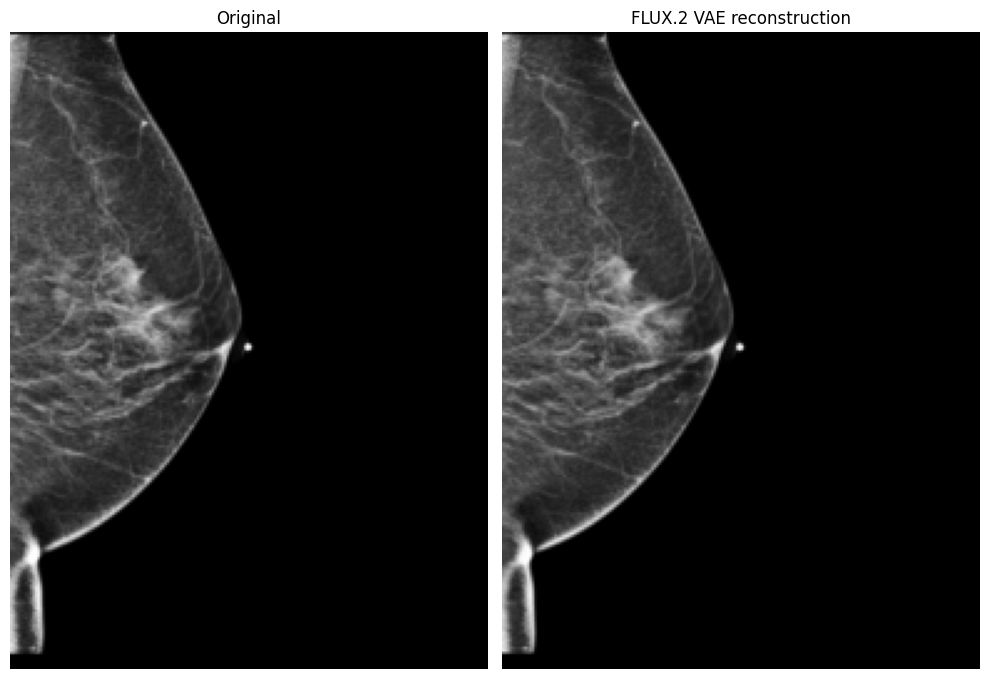

In [16]:
plt.figure(figsize=(10, 7))

plt.subplot(1, 2, 1)

plt.imshow(
    x_vis[0, 0].cpu(),
    cmap="gray",
)

plt.title("Original")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    x_rec_vis[0, 0].cpu(),
    cmap="gray",
)

plt.title("FLUX.2 VAE reconstruction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
mae = (
    x_vis.cpu()
    - x_rec_vis.cpu()
).abs().mean()

mse = (
    (
        x_vis.cpu()
        - x_rec_vis.cpu()
    ) ** 2
).mean()

print("MAE:", mae.item())
print("MSE:", mse.item())

MAE: 0.0055919610895216465
MSE: 0.00013038823090028018


In [18]:
with torch.inference_mode():
    z1 = vae.encode(x)
    z2 = vae.encode(x)

diff = (
    z1.float()
    - z2.float()
).abs()

print(
    "mean latent difference:",
    diff.mean().item(),
)

print(
    "max latent difference:",
    diff.max().item(),
)

mean latent difference: 0.0
max latent difference: 0.0


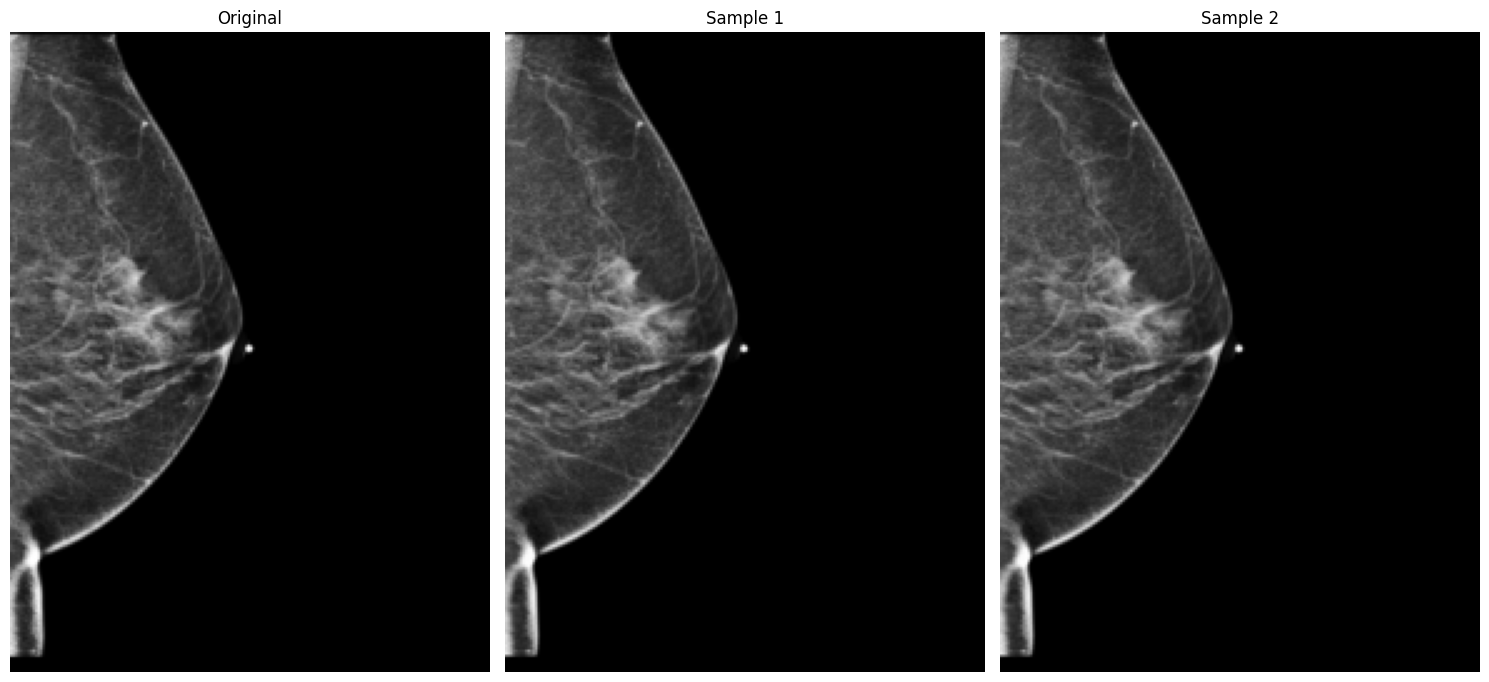

In [19]:
with torch.inference_mode():
    rec1 = vae.decode(z1)
    rec2 = vae.decode(z2)

rec1 = (
    (rec1.float() + 1) / 2
).clamp(0, 1)

rec2 = (
    (rec2.float() + 1) / 2
).clamp(0, 1)

plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.imshow(
    x_vis[0, 0].cpu(),
    cmap="gray",
)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    rec1[0, 0].cpu(),
    cmap="gray",
)
plt.title("Sample 1")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    rec2[0, 0].cpu(),
    cmap="gray",
)
plt.title("Sample 2")
plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
def load_one_image(row):

    image_path = row["image_path"]

    if not os.path.isabs(
        str(image_path)
    ):
        image_path = (
            DATA_DIR / image_path
        )

    image_np = preprocess_breast(
        image_path
    )

    x = transform(image_np)

    return x

In [21]:
batch_indices = [
    0,
    1,
    2,
    3,
]

xs = []

for idx in batch_indices:
    xs.append(
        load_one_image(
            df.iloc[idx]
        )
    )

x_batch = torch.stack(
    xs,
    dim=0,
)

print(
    "before normalization:",
    x_batch.shape,
)

before normalization: torch.Size([4, 1, 256, 192])


In [22]:
x_batch = (
    x_batch * 2.0 - 1.0
)

x_batch = x_batch.to(
    DEVICE
)

In [23]:
x_batch = x_batch.to(
    dtype=next(vae.parameters()).dtype
)
with torch.inference_mode():
    z_batch = vae.encode(
        x_batch
    )

print(
    "x:",
    x_batch.shape,
)

print(
    "z:",
    z_batch.shape,
)

x: torch.Size([4, 1, 256, 192])
z: torch.Size([4, 32, 32, 24])


In [24]:
z_float = z_batch.float()

print(
    "global mean:",
    z_float.mean().item(),
)

print(
    "global std:",
    z_float.std().item(),
)

global mean: 0.011325664818286896
global std: 1.4245116710662842


In [25]:
channel_mean = z_float.mean(
    dim=(0, 2, 3)
)

channel_std = z_float.std(
    dim=(0, 2, 3)
)

print(
    "channel mean shape:",
    channel_mean.shape,
)

print(
    "channel std shape:",
    channel_std.shape,
)

print(channel_mean)
print(channel_std)

channel mean shape: torch.Size([32])
channel std shape: torch.Size([32])
tensor([ 0.7168,  0.2173,  0.0405, -1.3654, -1.3631, -0.2793,  0.1004, -0.8625,
         1.3862, -0.0060,  0.0654,  0.0211,  0.5645,  0.7174,  1.2293,  0.1644,
         0.9322, -0.3854, -0.1287,  0.3166, -0.1265,  0.0898, -0.9698, -0.1747,
         0.0628,  0.6007,  0.0693,  0.2147, -0.7679, -0.1144, -1.0671,  0.4639],
       device='cuda:0')
tensor([0.8615, 1.1138, 1.5300, 1.3602, 1.2731, 1.6232, 0.7438, 1.5076, 1.3466,
        1.2034, 1.3824, 0.6547, 0.9701, 1.3503, 1.1068, 0.9764, 1.2084, 1.3730,
        1.2615, 1.0988, 1.4200, 1.3099, 1.0048, 1.1415, 1.2886, 1.1869, 1.3595,
        1.6934, 1.3221, 1.7695, 1.0362, 1.1461], device='cuda:0')


In [26]:
test_latent_path = (
    PROJECT_ROOT
    / "test_flux2_latent.pt"
)

torch.save(
    {
        "latent": z.cpu(),
        "image_path": str(image_path),
    },
    test_latent_path,
)

print(
    "saved:",
    test_latent_path,
)

saved: /vol/biomedic3/tx1215/mamo-flow/test_flux2_latent.pt
